# Task 1

In [1]:
import os
import cv2
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(2137)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"[*] Using device: {device}")

[*] Using device: mps


In [3]:
COLOR_MAP = {
    (60, 16, 152): 0,    # Building
    (132, 41, 246): 1,   # Land
    (110, 193, 228): 2,  # Road
    (254, 221, 58): 3,   # Vegetation
    (226, 169, 41): 4,   # Water
    (155, 155, 155): 5   # Unlabeled
}

CLASS_NAMES = ["Building", "Land", "Road", "Vegetation", "Water", "Unlabeled"]

In [4]:
def rgb_to_mask(rgb_mask):
    mask = np.zeros((rgb_mask.shape[0], rgb_mask.shape[1]), dtype=np.int64)
    for rgb, idx in COLOR_MAP.items():
        match = np.all(rgb_mask == rgb, axis=-1)
        mask[match] = idx
    return mask

In [5]:
class AerialImageryDataset(Dataset):
    def __init__(self, root_dir, image_size=(256, 256)):
        self.image_size = image_size
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, "*Tile*", "images", "*.jpg")))
        self.mask_paths = sorted(glob.glob(os.path.join(root_dir, "*Tile*", "masks", "*.png")))
        
        if len(self.image_paths) == 0:
            raise FileNotFoundError(f"[!] No images found in {root_dir}.")
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_rgb = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        
        image = cv2.resize(image, self.image_size)
        mask_rgb = cv2.resize(mask_rgb, self.image_size, interpolation=cv2.INTER_NEAREST)
        
        mask = rgb_to_mask(mask_rgb)
        
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))
        
        return torch.tensor(image), torch.tensor(mask)

In [6]:
DATA_DIR = "./Semantic segmentation dataset/"
dataset = AerialImageryDataset(DATA_DIR)

In [7]:
print("[*] Analizowanie rozkladu klas w zbiorze danych...")
class_counts = np.zeros(len(CLASS_NAMES))
for i in range(len(dataset)):
    _, mask = dataset[i]
    for c in range(len(CLASS_NAMES)):
        class_counts[c] += torch.sum(mask == c).item()

total_pixels = class_counts.sum()
print("\nROZKLAD KLAS (procent pikseli w całym zbiorze danych)")
for name, count in zip(CLASS_NAMES, class_counts):
    print(f"{name:15}: {count:12,.0f} px | {count / total_pixels * 100:6.2f}%")

[*] Analizowanie rozkladu klas w zbiorze danych...

ROZKLAD KLAS (procent pikseli w całym zbiorze danych)
Building       :      564,688 px |  11.97%
Land           :    2,231,239 px |  47.29%
Road           :      424,537 px |   9.00%
Vegetation     :      465,396 px |   9.86%
Water          :      990,277 px |  20.99%
Unlabeled      :       42,455 px |   0.90%


## Visualizing Interesting Examples

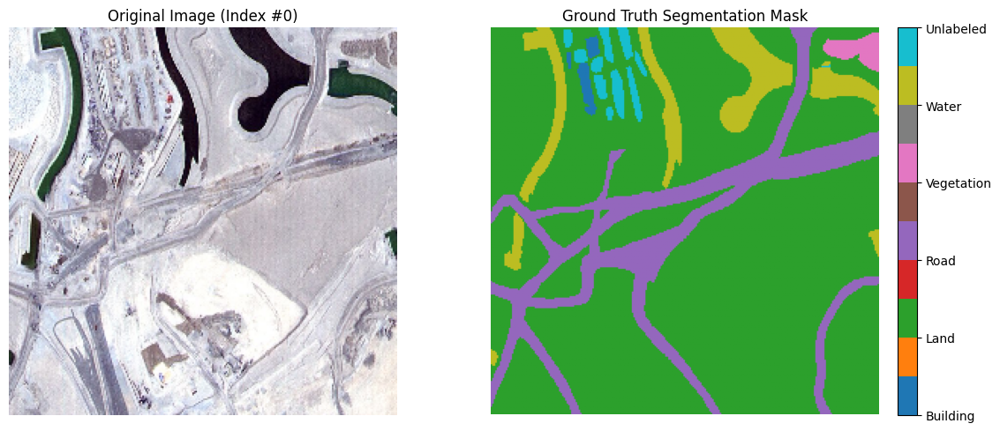

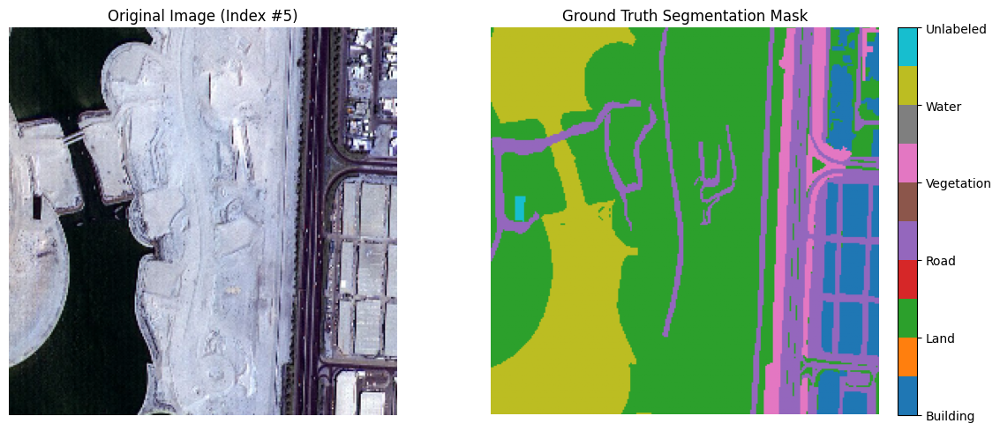

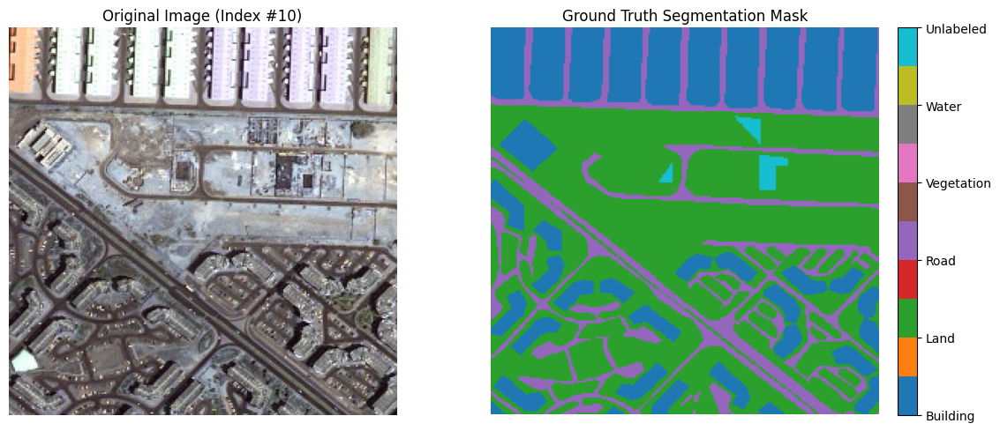

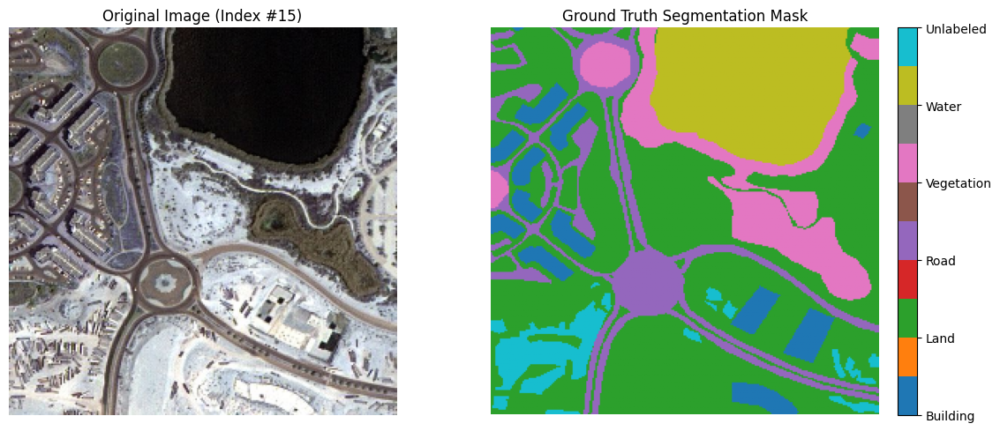

In [8]:
indices_to_show = [0, 5, 10, 15]
for idx in indices_to_show:
    img, mask = dataset[idx]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[0].set_title(f"Original Image (Index #{idx})")
    axes[0].axis("off")
    
    im = axes[1].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=5)
    axes[1].set_title("Ground Truth Segmentation Mask")
    axes[1].axis("off")
    
    cbar = fig.colorbar(im, ax=axes[1], ticks=list(range(6)), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(CLASS_NAMES)
    
    plt.tight_layout()
    plt.show()

## Step 2: Architecture Implementation & Network Training

(poglądowo ten rysunek)

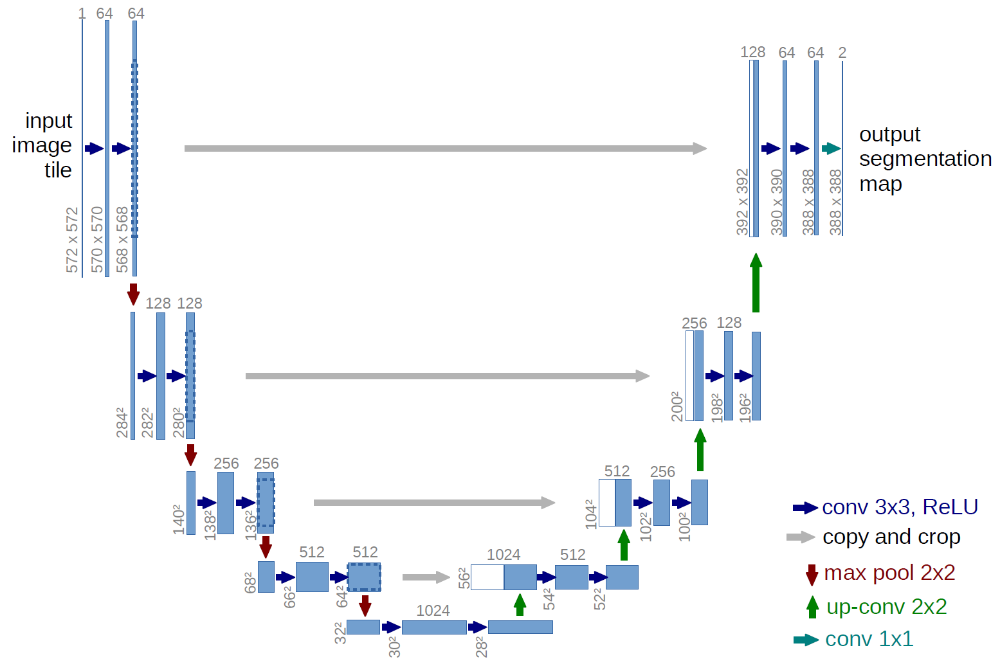

In [9]:
class UNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        
        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
            
        # Encoder
        self.enc1 = double_conv(3, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.enc2 = double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.enc3 = double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.bottleneck = double_conv(256, 512)
        
        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = double_conv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = double_conv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = double_conv(128, 64)
        
        # Final 1x1 Convolution
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)
        
        s3 = self.enc3(p2)
        p3 = self.pool3(s3)
        
        # Bottleneck
        b = self.bottleneck(p3)
        
        # Decoder with Skip Connections
        u3 = self.up3(b)
        c3 = torch.cat([u3, s3], dim=1)
        d3 = self.dec3(c3)
        
        u2 = self.up2(d3)
        c2 = torch.cat([u2, s2], dim=1)
        d2 = self.dec2(c2)
        
        u1 = self.up1(d2)
        c1 = torch.cat([u1, s1], dim=1)
        d1 = self.dec1(c1)
        
        return self.final_conv(d1)

In [10]:
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

model = UNet(num_classes=6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 10
losses = []

print(f"[*] Starting training on device: {device}")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * images.size(0)
        
    epoch_loss /= len(dataset)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} | Cross-Entropy Loss: {epoch_loss:.4f}")

[*] Starting training on device: mps
Epoch 01/10 | Cross-Entropy Loss: 1.2397
Epoch 02/10 | Cross-Entropy Loss: 0.9376
Epoch 03/10 | Cross-Entropy Loss: 0.8633
Epoch 04/10 | Cross-Entropy Loss: 0.7989
Epoch 05/10 | Cross-Entropy Loss: 0.7776
Epoch 06/10 | Cross-Entropy Loss: 0.7582
Epoch 07/10 | Cross-Entropy Loss: 0.7228
Epoch 08/10 | Cross-Entropy Loss: 0.7449
Epoch 09/10 | Cross-Entropy Loss: 0.7204
Epoch 10/10 | Cross-Entropy Loss: 0.7194


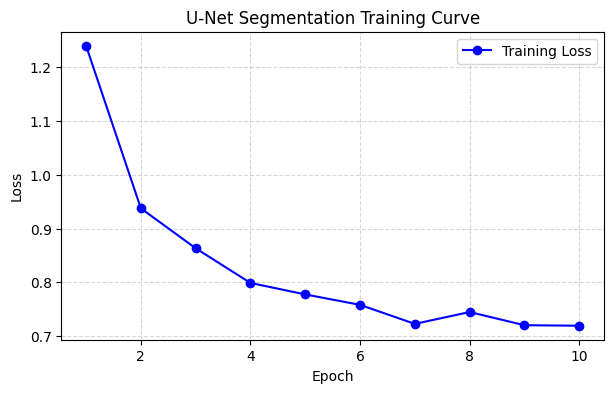

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), losses, 'b-o', label='Training Loss')
plt.title("U-Net Segmentation Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

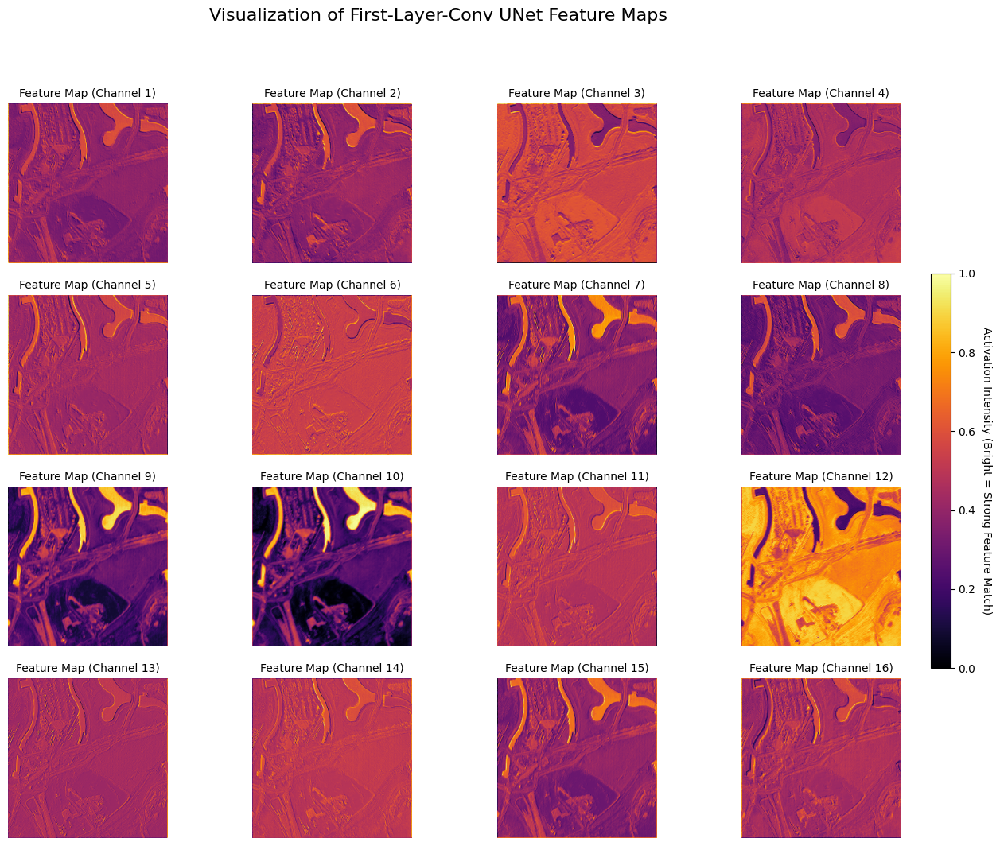

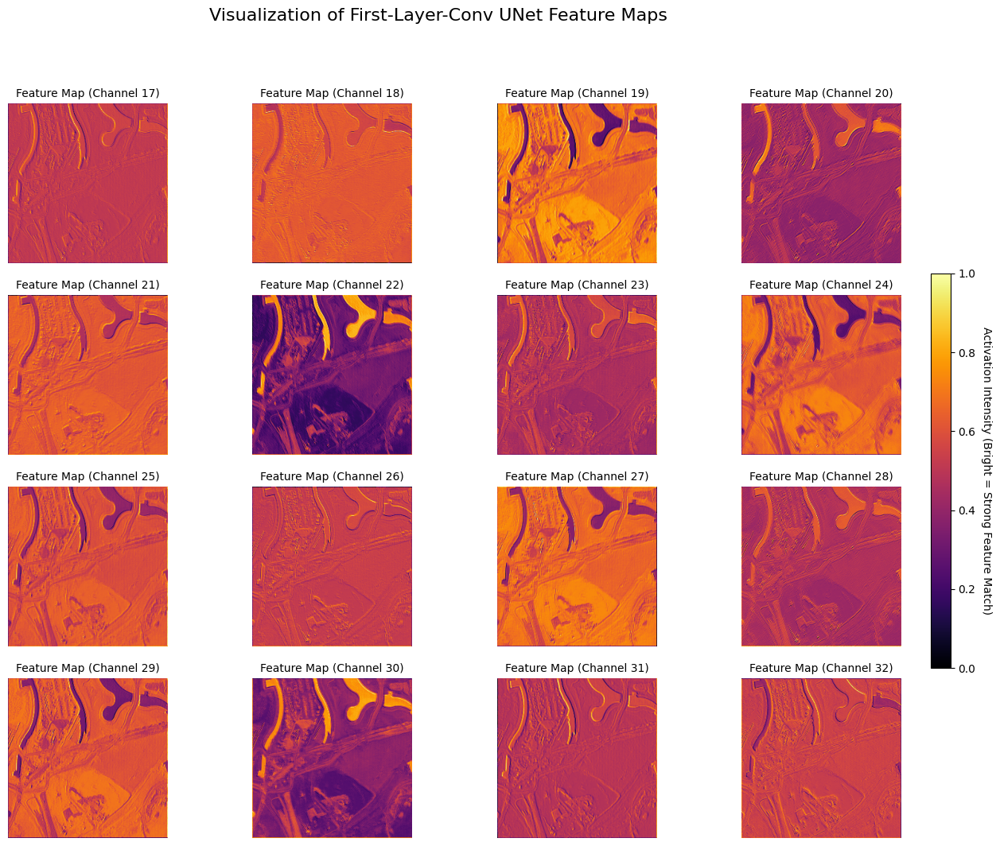

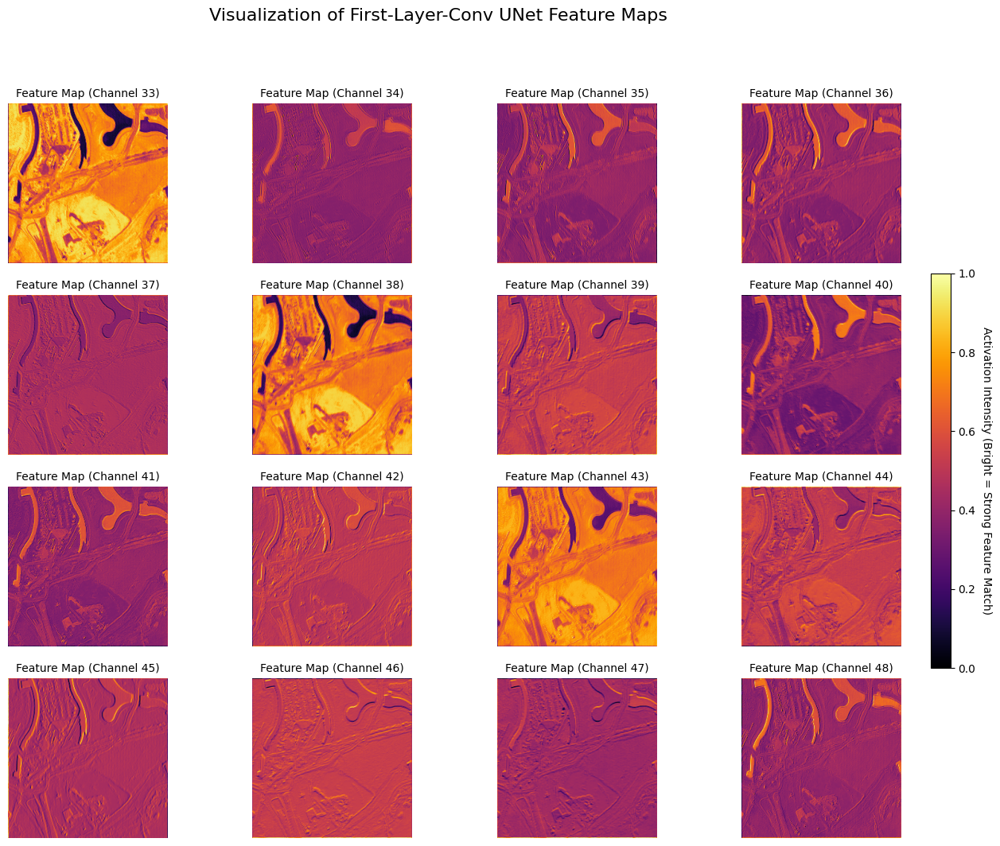

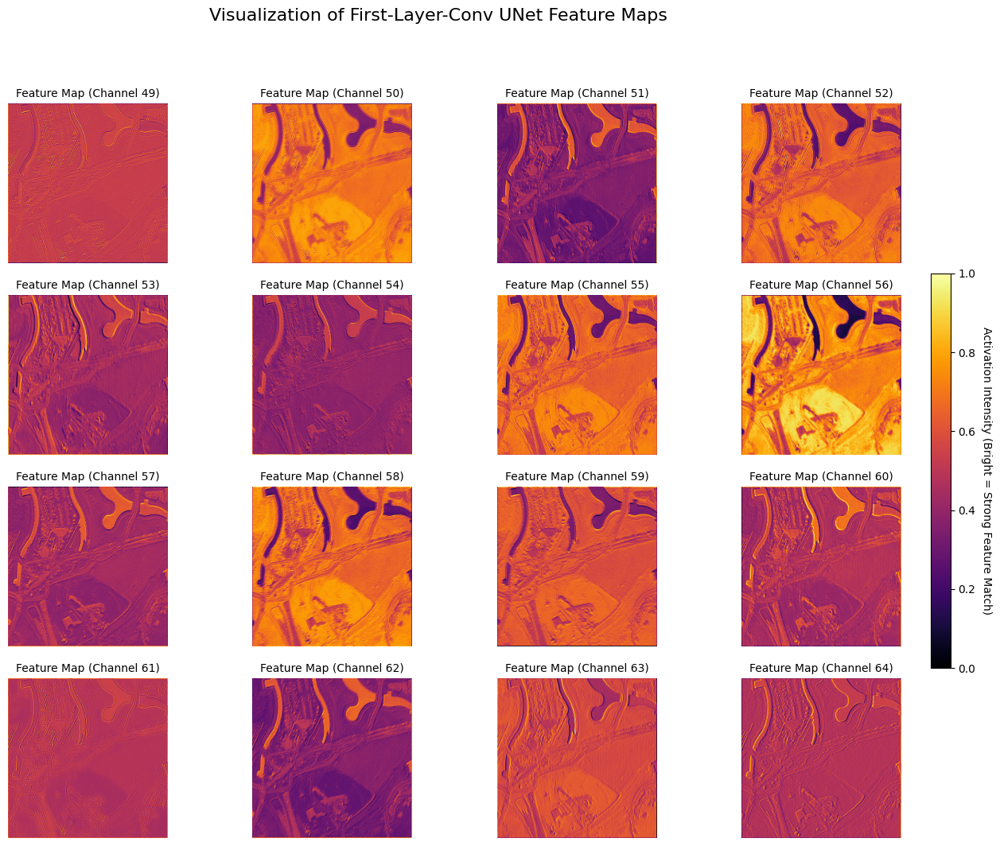

In [ ]:
model.eval()

img, mask = dataset[0]
input_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = model.enc1[0](input_tensor)
    feature_maps = feature_maps.squeeze(0).cpu().numpy()  # Kształt: [64, 256, 256]

for _ in range(4):
    # Rysujemy siatkę 4x4 dla 16 map cech
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))

    for i, ax in enumerate(axes.flat):
        f_map = feature_maps[_ * 16 + i, :, :]
        
        # Normalizacja Min-Max dla idealnego kontrastu na wykresie
        f_map = (f_map - f_map.min()) / (f_map.max() - f_map.min() + 1e-8)
        
        im = ax.imshow(f_map, cmap="inferno")
        ax.set_title(f"Feature Map (Channel {_ * 16 + i+1})", fontsize=10)
        ax.axis("off")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.03)
    cbar.set_label("Activation Intensity (Bright = Strong Feature Match)", rotation=270, labelpad=15)

    plt.suptitle("Visualization of First-Layer-Conv UNet Feature Maps ", fontsize=16, y=0.98)
    plt.show()

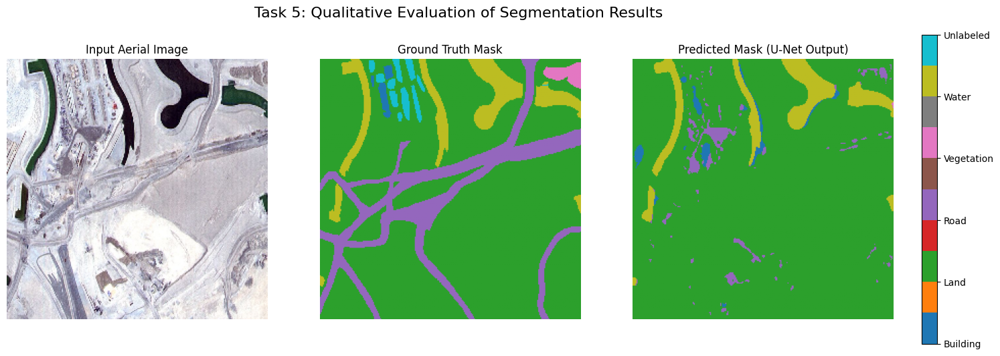

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor)
    pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Oryginalny obraz wejściowy (powrót z CHW do HWC)
ax[0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
ax[0].set_title("Input Aerial Image", fontsize=12)
ax[0].axis("off")

# Maska referencyjna (Ground Truth)
ax[1].imshow(mask.numpy(), cmap="tab10", vmin=0, vmax=5)
ax[1].set_title("Ground Truth Mask", fontsize=12)
ax[1].axis("off")

# Predykcja wygenerowana przez sieć U-Net
im_pred = ax[2].imshow(pred_mask, cmap="tab10", vmin=0, vmax=5)
ax[2].set_title("Predicted Mask (U-Net Output)", fontsize=12)
ax[2].axis("off")

# Dodanie czytelnej legendy klas po prawej stronie
cbar_classes = fig.colorbar(im_pred, ax=ax.ravel().tolist(), ticks=list(range(6)), fraction=0.02, pad=0.03)
cbar_classes.ax.set_yticklabels(CLASS_NAMES)

plt.suptitle("Segmentation Results", fontsize=16, y=0.95)
plt.show()

Ewidętnie gorzej radzi sobie z drogami

# Task 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def can_expand(active_stay_region, i, C_indices, X, eps, delta):
    if len(active_stay_region) == 0:
        return False
    
    last_point_idx = active_stay_region[-1]
    # Odległość euklidesowa w przestrzeni 2D (kolumny 0 i 1)
    dist = np.linalg.norm(X[last_point_idx, :2] - X[i, :2])
    
    if dist <= eps:
        return True
    
    # Jeśli obiekt wyszedł poza eps, sprawdzamy tolerancję czasową delta (oś Z / kolumna 2 / indeksy)
    if (i - last_point_idx) <= delta:
        distances_to_C = np.linalg.norm(X[C_indices, :2] - X[i, :2], axis=1)
        if np.any(distances_to_C <= eps):
            return True
            
    return False

def find_msr(P_indices, X, eps, K):
    if len(P_indices) < K:
        return []
    
    for i in range(len(P_indices) - K + 1):
        window = P_indices[i : i + K]
        valid = True
        for idx in window:
            dists = np.obtain_distances = np.linalg.norm(X[window, :2] - X[idx, :2], axis=1)
            if np.sum(dists <= eps) < (K / 2):
                valid = False
                break
        if valid:
            return list(window)
    return []

def seq_scan(X, eps, K, delta):
    n = len(X)
    labels = np.full(n, -1)
    stay_regions_set = []
    
    C = []  # Context
    P = []  # Pool
    active_stay_region = []
    current_cluster_id = 0
    
    for i in range(n):
        C.append(i)
        
        if len(active_stay_region) > 0 and can_expand(active_stay_region, i, C, X, eps, delta):
            active_stay_region.append(i)
            labels[i] = current_cluster_id
            P = []  
        else:
            P.append(i)
            next_stay_region = find_msr(P, X, eps, K)
            
            if len(next_stay_region) > 0:
                if len(active_stay_region) > 0:
                    stay_regions_set.append(active_stay_region)
                    current_cluster_id += 1
                
                active_stay_region = next_stay_region
                for idx in active_stay_region:
                    labels[idx] = current_cluster_id
                
                C = list(P)
                P = []
                
    return labels

In [103]:
import numpy as np

np.random.seed(42)
X_list = []
current_time = 0

r = 1.0
center_x, center_y = 10.0, 10.0

circle_start_x = center_x + r
circle_start_y = center_y

# 1. STAY REGION A (Start: fluktuacje wokół 0,0)
for t in range(60):
    x_pos = 0.0 + np.random.normal(0, 0.50)
    y_pos = 0.0 + np.random.normal(0, 0.50)
    X_list.append([x_pos, y_pos, current_time])
    current_time += 1

# 2. TRANSITION 1 (Ruch z 0,0 bezpośrednio do PUNKTU STARTOWEGO OKRĘGU)
transition_steps = 120
x_steps = np.linspace(0.0, circle_start_x, transition_steps)
y_steps = np.linspace(0.0, circle_start_y, transition_steps)
for x, y in zip(x_steps, y_steps):
    X_list.append([x + np.random.normal(0, 0.10), y + np.random.normal(0, 0.10), current_time])
    current_time += 1

# 3. STAY REGION B (Kręcenie się w kółko)
angles = np.linspace(0, 4 * np.pi, 120)  # dwa pełne obroty
for angle in angles:
    x_pos = center_x + r * np.cos(angle) + np.random.normal(0, 0.15)
    y_pos = center_y + r * np.sin(angle) + np.random.normal(0, 0.15)
    X_list.append([x_pos, y_pos, current_time])
    current_time += 1

# 4. TRANSITION 2 (Powrót z punktu końcowego okręgu (do nowej bazy docelowej 0,10)
return_steps = 120
x_return = np.linspace(circle_start_x, 0.0, return_steps)
y_return = np.linspace(circle_start_y, 10.0, return_steps)
for x, y in zip(x_return, y_return):
    X_list.append([x + np.random.normal(0, 0.10), y + np.random.normal(0, 0.10), current_time])
    current_time += 1

# 5. STAY REGION C (Zatrzymanie w punkcie końcowym 0,10)
for t in range(60):
    x_pos = 0.0 + np.random.normal(0, 0.50)
    y_pos = 10.0 + np.random.normal(0, 0.50)
    X_list.append([x_pos, y_pos, current_time])
    current_time += 1

n_corrupted_points = 60
total_samples = len(X_list)

corrupt_indices = np.random.choice(total_samples, size=n_corrupted_points, replace=False)

X_list = np.array(X_list)

for idx in corrupt_indices:
    X_list[idx, 0] += np.random.uniform(-4.0, 4.0)
    X_list[idx, 1] += np.random.uniform(-4.0, 4.0)

X_spatiotemporal = X_list
X_spatiotemporal = X_spatiotemporal[np.argsort(X_spatiotemporal[:, 2])]

print(f"    Total points: {X_spatiotemporal.shape[0]} | Shape: {X_spatiotemporal.shape}")

    Total points: 480 | Shape: (480, 3)


In [104]:
import plotly.graph_objects as go
import numpy as np

EPS_2D = 0.75   
K_2D = 15       # Podnosimy próg punktów, żeby regiony stania były wyraźne, a ruch odrzucony
DELTA_2D = 0    # Delta = 0 oznacza natychmiastowe szukanie nowego klastra przy opuszczeniu EPS

labels = seq_scan(X_spatiotemporal, eps=EPS_2D, K=K_2D, delta=DELTA_2D)

x_coords = X_spatiotemporal[:, 0]
y_coords = X_spatiotemporal[:, 1]
time_coords = X_spatiotemporal[:, 2]

min_time = time_coords.min()
max_time = time_coords.max()

fig = go.Figure()

# ŚLAD 1: Szara linia trajektorii
fig.add_trace(go.Scatter3d(
    x=x_coords, y=y_coords, z=time_coords,
    mode='lines',
    line=dict(color='rgba(150, 150, 150, 0.25)', width=2.5),
    name='Chronological Path',
    hoverinfo='none',
    showlegend=True
))

# ŚLAD 2: Punkty ruchu / tranzycji oraz globalny szum (-1)
mask_noise = (labels == -1)
fig.add_trace(go.Scatter3d(
    x=x_coords[mask_noise], 
    y=y_coords[mask_noise], 
    z=time_coords[mask_noise],
    mode='markers',
    marker=dict(
        size=4,
        color='rgba(239, 85, 59, 0.7)', # Czerwone krzyżyki dla fazy poruszania się
        symbol='x',
        line=dict(color='black', width=0.3)
    ),
    text=[f"Noise / Transition<br>Time: {t}" for t in time_coords[mask_noise]],
    hoverinfo='text',
    name='Noise / Transition'
))

# ŚLADY 3+: Wykryte, odseparowane Stay Regions z heatmapą
unique_clusters = sorted([lbl for lbl in np.unique(labels) if lbl != -1])
print(f"[+] Algorytm SeqScan wykrył poprawnie: {len(unique_clusters)} regiony przebywania.")

for idx, cluster_id in enumerate(unique_clusters):
    mask_cluster = (labels == cluster_id)
    show_colorbar = (idx == 0)
    
    fig.add_trace(go.Scatter3d(
        x=x_coords[mask_cluster], 
        y=y_coords[mask_cluster], 
        z=time_coords[mask_cluster],
        mode='markers',
        marker=dict(
            size=7.5,
            color=time_coords[mask_cluster],
            colorscale='Viridis',
            cmin=min_time,
            cmax=max_time,
            colorbar=dict(title="Time Step", thickness=15) if show_colorbar else None,
            symbol='circle',
            opacity=0.9,
            line=dict(color='black', width=0.5)
        ),
        text=[f"Stay Region {cluster_id + 1}<br>Time: {t}" for t in time_coords[mask_cluster]],
        hoverinfo='text',
        name=f'Stay Region {cluster_id + 1}'
    ))

fig.update_layout(
    title=dict(
        text=f"Fixed SeqScan 3D: Successfully Separated {len(unique_clusters)} Regions (Eps={EPS_2D}, K={K_2D})",
        x=0.5,
        font=dict(size=14)
    ),
    scene=dict(
        xaxis_title='Space X',
        yaxis_title='Space Y',
        zaxis_title='Time (Growing Upwards)',
        zaxis=dict(autorange=True),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1.2)
    ),
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(yanchor="top", y=0.95, xanchor="left", x=0.02, font=dict(size=11), bgcolor="rgba(30, 30, 30, 0.8)"),
    template="plotly_dark"
)

fig.show()

[+] Algorytm SeqScan wykrył poprawnie: 1 regiony przebywania.


# Task 3

## Jak działa algorytm TRACLUS?

* Algorytmy klasteryzacji trajektorii traktują każdą ścieżkę jako jedną całość. 
* To podejście zawodzi, gdy trajektorie są długie, a obiekty poruszają się wspólnie tylko na pewnych odcinkach (np. samochody jadące z różnych osiedli, które na 10 kilometrów łączą się na tej samej autostradzie, a potem znowu się rozjeżdżają).

TRACLUS (Trajectory Clustering) Składa się z dwóch głównych faz:

Dzielenie: Każda długa trajektoria jest sekwencyjnie dzielona na zbiór mniejszych, prostoliniowych odcinków (szum i zakręty są wygładzane). Wykorzystuje się do tego zasadę MDL (Minimum Description Length), która szuka kompromisu między dokładnością od wzorowania a stopniem kompresji danych.

Łączenie (Klastrowanie): Wszystkie wycięte odcinki ze wszystkich trajektorii wrzucane są do jednego worka. Następnie algorytm typu DBSCAN grupuje te odcinki, które leżą blisko siebie, są do siebie równoległe i mają podobny kierunek.

Dzięki temu TRACLUS potrafi wykryć „wspólne sub-trasy”, ignorując fakt, że całe trajektorie początkowe i końcowe były zupełnie inne.

---

$L(H)$ – Koszt Hipotezy (Compression Cost): Długość opisu uproszczonej trajektorii. Im mniej odcinków użyjemy do opisania trasy, tym ten koszt jest mniejszy (zyskujemy na kompresji).

$L(D|H)$ – Koszt Danych przy danej Hipotezie (Difference Cost): Suma błędów odwzorowania. Im bardziej upraszczamy linię, tym bardziej odbiega ona od rzeczywistych, oryginalnych punktów GPS, co drastycznie podbija ten koszt.

---

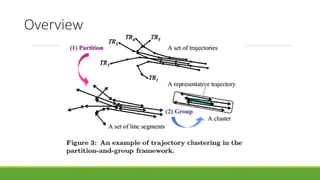

## Algorytm Partycjonowania: 
Analizujemy jedną trajektorię składającą się z punktów $p_1, p_2, \dots, p_n$


Ustawiamy punkt startowy podziału jako $p_{start} = p_1$, a aktualny sprawdzany indeks jako $i = start + 2$. 


Obliczamy dwie wartości MDL dla aktualnego podzbioru punktów od $p_{start}$ do $p_i$:  
$MDL_{no\_par}$ (koszt bez podziału): Trajektoria na tym odcinku jest opisana dokładnie tak, jak zarejestrował ją GPS.  
$MDL_{par}$ (koszt z podziałem): Zakładamy hipotezę, że punkty pomiędzy $p_{start}$ a $p_i$ można scalić w jedną prostą linię łączącą $p_{start}$ bezpośrednio z $p_i$.

Warunek podziału: Jeśli $MDL_{no\_par} > MDL_{par}$, oznacza to, że uproszczenie linii daje nam zysk informacyjny. Idziemy dalej, zwiększając $i \leftarrow i + 1$. 

W momencie, gdy nagle $MDL_{no\_par} < MDL_{par}$, oznacza to, że błąd przybliżenia prostą linią stał się zbyt drastyczny (obiekt mocno skręcił).  

Przypisujemy punkt $p_{i-1}$ jako oficjalny punkt podziału, zapisujemy wycięty odcinek od $p_{start}$ do $p_{i-1}$, po czym resetujemy procedurę, ustawiając $p_{start} = p_{i-1}$.


## Klasteryzacja Odcinków (Ważony DBSCAN)
Po zakończeniu fazy pierwszej zapominamy o pojęciu "całej trajektorii".

Wszystkie wycięte, krótkie odcinki ze wszystkich trajektorii trafiają do wspólnej przestrzeni.

Do ich pogrupowania TRACLUS wykorzystuje zmodyfikowany algorytm DBSCAN.

Kluczową innowacją jest tutaj funkcja odległości linii (Line Distance Function). 

Zwykły DBSCAN liczy odległość między punktami. 

TRACLUS liczy odległość między dwoma skierowanymi odcinkami $L_i$ oraz $L_j$ jako sumę trzech niezależnych składowych:

$$\text{dist}(L_i, L_j) = d_\perp(L_i, L_j) + d_\parallel(L_i, L_j) + d_\theta(L_i, L_j)$$

### a) What is the time complexity of the approximate algorithm used for trajectory partitioning in the TRACLUS algorithm? Provide a justification for your answer.
Liniowa. Sekencyjnie i zachładnnie porcesujemy wzsystkie punkty.


### d) Metric Properties and Counterexample 

Oryginalna funkcja odległości TRACLUS **nie jest poprawną metryką**, ponieważ komponent odległości równoległej ($d_\parallel$) oparty na nakładaniu się rzutów (overlap) **łamie nierówność trójkąta**.

**Kontrprzykład:**
Rozważmy trzy poziome, równoległe odcinki na płaszczyźnie 2D:

* Odcinek $A$: od $(0, 0)$ do $(2, 0)$
* Odcinek $B$: od $(1, 1)$ do $(3, 1)$
* Odcinek $C$: od $(2.1, 0)$ do $(4.1, 0)$

$\text{dist}(A, B) = \frac{1^2 + 1^2}{1+1} + 1 + 0 = 2$


$\text{dist}(B, C) = \frac{1^2 + 1^2}{1+1} + 1.1 + 0 = 2.1$

$\text{dist}(A, C) = 0 + (2.1 + 2.1)+ 0 = 4.2$

c) [1 point] Let’s consider hurricane trajectories. Intuitively, stronger hurricanes should have
higher weights when calculating the loss function Nε . How could you modify a density-based
clustering algorithm for line segmentation to take trajectory weights into account?

Można dawać różne wagi przy tych cześciach odległości, które uważamy za istotniejsze

b) [0.5 points] Give an example where the approximate algorithm for trajectory partitioning fails
to find the optimal partitioning.



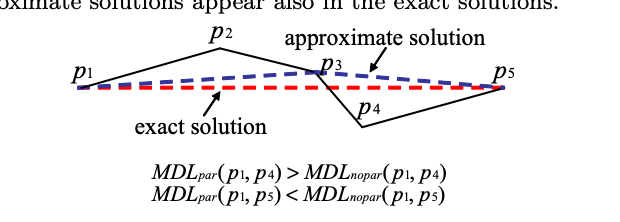